In [1]:
import torch
import torch.nn as nn
import os
import os.path as osp
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import json
import numpy as np
from PIL import ImageDraw
import torch.utils.data as data
import torch.nn.functional as F
import random

In [2]:
class Args:
    gpu_ids = [0, 1, 2, 3]
    batchSize = 1
    dataroot = '../../DeepFashion_Try_On/acgpn_dataset'
    datapairs = 'custom.txt'
    phase = 'test'

opt = Args

In [3]:
def make_dataset(dir):
    images = []
    assert os.path.isdir(dir), '%s is not a valid directory' % dir
    f = dir.split('/')[-1].split('_')[-1]
    dirs= os.listdir(dir)
    for img in dirs:
        path = os.path.join(dir, img)
        #print(path)
        images.append(path)
    return images

def get_params(opt, size):
    w, h = size
    new_h = h
    new_w = w
    if opt.resize_or_crop == 'resize_and_crop':
        new_h = new_w = opt.loadSize            
    elif opt.resize_or_crop == 'scale_width_and_crop':
        new_w = opt.loadSize
        new_h = opt.loadSize * h // w

    x = random.randint(0, np.maximum(0, new_w - opt.fineSize))
    y = random.randint(0, np.maximum(0, new_h - opt.fineSize))

def get_transform(method=Image.BICUBIC, normalize=True):
        transform_list = []
        transform_list += [transforms.ToTensor()]
        if normalize:
            transform_list += [transforms.Normalize((0.5, 0.5, 0.5),
                                                    (0.5, 0.5, 0.5))]
        return transforms.Compose(transform_list)
    
class BaseDataset(data.Dataset):
    def __init__(self, opt):
        self.opt = opt
        super(BaseDataset, self).__init__()
        
        human_names = []
        cloth_names = []
        with open(os.path.join(opt.dataroot, opt.datapairs), 'r') as f:
            for line in f.readlines():
                h_name, c_name = line.strip().split()
                human_names.append(h_name)
                cloth_names.append(c_name)
        self.human_names = human_names
        self.cloth_names = cloth_names
        
    def image_for_pose(self, pose_name, transform):
        with open(osp.join(pose_name), 'r') as f:
            pose_label = json.load(f)
            pose_data = pose_label['people'][0]['pose_keypoints']
            pose_data = np.array(pose_data)
            pose_data = pose_data.reshape((-1,3))
        point_num = pose_data.shape[0]
        fine_height = 256
        fine_width = 192
        pose_map = torch.zeros(point_num, fine_height, fine_width)
        r = 5
        im_pose = Image.new('L', (fine_width, fine_height))
        pose_draw = ImageDraw.Draw(im_pose)
        for i in range(point_num):
            one_map = Image.new('L', (fine_width, fine_height))
            draw = ImageDraw.Draw(one_map)
            pointx = pose_data[i,0]
            pointy = pose_data[i,1]
            if pointx > 1 and pointy > 1:
                draw.rectangle((pointx-r, pointy-r, pointx+r, pointy+r), 'white', 'white')
                pose_draw.rectangle((pointx-r, pointy-r, pointx+r, pointy+r), 'white', 'white')
            one_map = transform(one_map.convert('RGB'))
            pose_map[i] = one_map[0]
        return pose_map

    def __getitem__(self, index):        
        c_name = self.cloth_names[index]
        h_name = self.human_names[index]
        A_path = osp.join(self.opt.dataroot, self.opt.phase ,self.opt.phase + '_label', h_name.replace(".jpg", ".png"))
        label = Image.open(A_path).convert('L')

        B_path = osp.join(self.opt.dataroot, self.opt.phase ,self.opt.phase + '_img', h_name)
        image = Image.open(B_path).convert('RGB') 

        E_path = osp.join(self.opt.dataroot, self.opt.phase ,self.opt.phase + '_edge', c_name)
        edge = Image.open(E_path).convert('L')
                
        C_path = osp.join(self.opt.dataroot, self.opt.phase ,self.opt.phase + '_color', c_name)
        color = Image.open(C_path).convert('RGB')
        
        S_path = osp.join(self.opt.dataroot, self.opt.phase ,self.opt.phase + '_posergb', h_name)
        skeleton = Image.open(S_path).convert('RGB')

        M_path = osp.join(self.opt.dataroot, self.opt.phase ,self.opt.phase + '_imgmask', h_name.replace('.jpg', '.png'))
        mask = Image.open(M_path).convert('L')
        mask_array = np.array(mask)
        parse_shape = (mask_array > 0).astype(np.float32)
        parse_shape_ori = Image.fromarray((parse_shape * 255).astype(np.uint8))
        parse_shape = parse_shape_ori.resize(
            (192 // 16, 256 // 16), Image.BILINEAR)
        mask = parse_shape.resize(
            (192, 256), Image.BILINEAR)

        transform_A = get_transform(method=Image.NEAREST, normalize=False)
        label_tensor = transform_A(label) * 255
        transform_B = get_transform()      
        image_tensor = transform_B(image)
        edge_tensor = transform_A(edge)
        color_tensor = transform_B(color)
        skeleton_tensor = transform_B(skeleton)
        mask_tensor = transform_A(mask)
        normal_tensor = transform_A(parse_shape_ori)
        pose_name = osp.join(self.opt.dataroot, self.opt.phase ,self.opt.phase + '_pose', h_name.replace('.jpg', '_keypoints.json'))
        #pose_map = self.image_for_pose(pose_name, transform_B)
        return {'label': label_tensor, 'image': image_tensor,
                             'edge': edge_tensor,'color': color_tensor, 
                             'mask': mask_tensor, 'name' : c_name,
                             'colormask': mask_tensor, 'skeleton': skeleton_tensor,
                             #'pose':pose_map,
                             'blurry': mask_tensor, 'normal': normal_tensor}
    def __len__(self):
        return len(self.human_names)

![architecture](web_data/g1_design.png)

In [4]:
t = BaseDataset(opt)
dataloader = torch.utils.data.DataLoader(
            t,
            batch_size=1,
            shuffle=False)

In [5]:
len(dataloader)

1

In [6]:
from torch.autograd import Variable

def changearm(old_label):
    label=old_label
    arm1=torch.FloatTensor((label.cpu().numpy()==11).astype(np.int))
    arm2=torch.FloatTensor((label.cpu().numpy()==13).astype(np.int))
    noise=torch.FloatTensor((label.cpu().numpy()==7).astype(np.int))
    label=label*(1-arm1)+arm1*4
    label=label*(1-arm2)+arm2*4
    label=label*(1-noise)+noise*4
    return label

position = -1 
for data in dataloader:
    position +=1
    if position == 0:
        all_clothes_label = changearm(data['label'])
        mask_clothes = torch.FloatTensor((data['label'].cpu().numpy() == 4).astype(np.int))
        mask_fore = torch.FloatTensor((data['label'].cpu().numpy() > 0).astype(np.int))
        img_fore = data['image'] * mask_fore

        in_label = Variable(data['label'].cuda())
        in_edge = Variable(data['edge'].cuda())
        in_img_fore = Variable(img_fore.cuda())
        in_mask_clothes = Variable(mask_clothes.cuda())
        in_color = Variable(data['color'].cuda())
        in_all_clothes_label = Variable(all_clothes_label.cuda())
        in_image = Variable(data['image'].cuda())
        in_mask_fore = Variable(mask_fore.cuda()) 
        in_skeleton = Variable(data['skeleton'].cuda())
        in_blurry = Variable(data['blurry'].cuda())
        break

C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  """
C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note lin

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


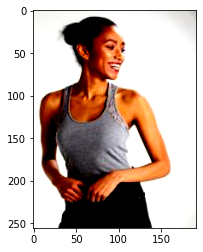

In [7]:
plt.imshow(in_image[0].permute(1,2,0).detach().cpu().numpy()+0.3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


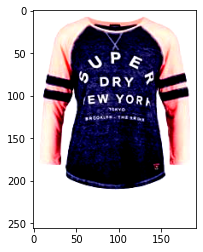

In [8]:
plt.imshow(in_color[0].permute(1,2,0).detach().cpu().numpy()+0.3)

## Architecture for G

<ul>
    <li>G1 will generate semantic labels</li>
    <li>G3 combines everthing together to produce a final image</li>
<ul>

In [9]:
class G1(nn.Module):
    def __init__(self, input_nc, output_nc=3):
        super(G1, self).__init__()
        nl = nn.InstanceNorm2d
        self.conv1 = nn.Sequential(*[nn.Conv2d(input_nc, 64, kernel_size=3, stride=1, padding=1), nl(64), nn.ReLU()])
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2))

        self.conv2 = nn.Sequential(*[nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU()])
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))

        self.conv3 = nn.Sequential(*[nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU()])
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))

        self.conv4 = nn.Sequential(*[nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU(),
                                     nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU()])
        self.drop4 = nn.Dropout(0.5)
        self.pool4 = nn.MaxPool2d(kernel_size=(2, 2))

        self.conv5 = nn.Sequential(*[nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1), nl(1024), nn.ReLU(),
                                     nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1), nl(1024), nn.ReLU()])
        self.drop5 = nn.Dropout(0.5)

        self.up6 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1), nl(512),
              nn.ReLU()])

        self.conv6 = nn.Sequential(*[nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU(),
                                     nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU()])
        self.up7 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1), nl(256),
              nn.ReLU()])
        self.conv7 = nn.Sequential(*[nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU()])

        self.up8 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1), nl(128),
              nn.ReLU()])

        self.drop6 = nn.Dropout(0.45)

        self.conv8 = nn.Sequential(*[nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU()])

        self.up9 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1), nl(64),
              nn.ReLU()])

        self.drop7 = nn.Dropout(0.45)

        self.conv9 = nn.Sequential(*[nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1), nl(64), nn.ReLU(),
                                     nn.Conv2d(
                                         64, output_nc, kernel_size=3, stride=1, padding=1)
                                     ])

    def forward(self, input):
        conv1 = self.conv1(input)
        pool1 = self.pool1(conv1)

        conv2 = self.conv2(pool1)
        pool2 = self.pool2(conv2)

        conv3 = self.conv3(pool2)
        pool3 = self.pool3(conv3)

        conv4 = self.conv4(pool3)
        drop4 = self.drop4(conv4)
        pool4 = self.pool4(drop4)

        conv5 = self.conv5(pool4)
        drop5 = self.drop5(conv5)

        up6 = self.up6(drop5)
        conv6 = self.conv6(torch.cat([drop4, up6], 1))

        up7 = self.up7(conv6)
        conv7 = self.conv7(torch.cat([conv3, up7], 1))

        up8 = self.up8(conv7)

        conv8 = self.drop6(self.conv8(torch.cat([conv2, up8], 1)))

        up9 = self.up9(conv8)
        conv9 = self.drop7(self.conv9(torch.cat([conv1, up9], 1)))
        return conv9


class Refine(nn.Module):
    def __init__(self, input_nc, output_nc=3):
        super(Refine, self).__init__()
        nl = nn.InstanceNorm2d
        self.conv1 = nn.Sequential(*[nn.Conv2d(input_nc, 64, kernel_size=3, stride=1, padding=1), nl(64), nn.ReLU(),
                                     nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nl(64), nn.ReLU()])
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Sequential(*[nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU(),
                                     nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU()])
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv3 = nn.Sequential(*[nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU(),
                                     nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU()])
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv4 = nn.Sequential(*[nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU(),
                                     nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU()])
        self.drop4 = nn.Dropout(0.5)
        self.pool4 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv5 = nn.Sequential(*[nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1), nl(1024), nn.ReLU(),
                                     nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1), nl(1024), nn.ReLU()])
        self.drop5 = nn.Dropout(0.5)
        self.up6 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1), nl(512),
              nn.ReLU()])
        self.conv6 = nn.Sequential(*[nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU(),
                                     nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU()])
        self.up7 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1), nl(256),
              nn.ReLU()])
        self.conv7 = nn.Sequential(*[nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU(),
                                     nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU()])
        self.up8 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1), nl(128),
              nn.ReLU()])
        self.conv8 = nn.Sequential(*[nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU(),
                                     nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU()])
        self.up9 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1), nl(64),
              nn.ReLU()])
        self.conv9 = nn.Sequential(*[nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1), nl(64), nn.ReLU(),
                                     nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nl(
                                         64), nn.ReLU(),
                                     nn.Conv2d(
                                         64, output_nc, kernel_size=3, stride=1, padding=1)
                                     ])
    def forward(self, input):
        conv1 = self.conv1(input)
        pool1 = self.pool1(conv1)
        conv2 = self.conv2(pool1)
        pool2 = self.pool2(conv2)
        conv3 = self.conv3(pool2)
        pool3 = self.pool3(conv3)
        conv4 = self.conv4(pool3)
        drop4 = self.drop4(conv4)
        pool4 = self.pool4(drop4)
        conv5 = self.conv5(pool4)
        drop5 = self.drop5(conv5)
        up6 = self.up6(drop5)
        conv6 = self.conv6(torch.cat([drop4, up6], 1))
        up7 = self.up7(conv6)
        conv7 = self.conv7(torch.cat([conv3, up7], 1))
        up8 = self.up8(conv7)
        conv8 = self.conv8(torch.cat([conv2, up8], 1))
        up9 = self.up9(conv8)
        conv9 = self.conv9(torch.cat([conv1, up9], 1))
        return conv9

In [10]:
with torch.no_grad():
    G1n = G1(7, 4)
    G1n.cuda(opt.gpu_ids[0])
    G1n.load_state_dict(torch.load('checkpoint/G1_blurry_mask_20_.pth'))
    G1n.eval()

In [11]:
import cv2

def gen_noise(shape):
    noise = np.zeros(shape, dtype=np.uint8)
    ### noise
    noise = cv2.randn(noise, 0, 255)
    noise = np.asarray(noise / 255, dtype=np.uint8)
    noise = torch.tensor(noise, dtype=torch.float32)
    return noise.cuda()

def encode_input(label_map, clothes_mask,all_clothes_label):
    size = label_map.size()
    oneHot_size = (size[0], 14, size[2], size[3])
    input_label = torch.cuda.FloatTensor(torch.Size(oneHot_size)).zero_()
    input_label = input_label.scatter_(1, label_map.data.long().cuda(), 1.0)

    masked_label= torch.cuda.FloatTensor(torch.Size(oneHot_size)).zero_()
    masked_label=masked_label.scatter_(1,(label_map*(1-clothes_mask)).data.long().cuda(), 1.0)

    c_label=torch.cuda.FloatTensor(torch.Size(oneHot_size)).zero_()
    c_label=c_label.scatter_(1,all_clothes_label.data.long().cuda(),1.0)

    input_label = Variable(input_label)

    return input_label,masked_label,c_label

pre_clothes_mask = torch.FloatTensor((in_edge.detach().cpu().numpy() > 0.5).astype(np.float)).cuda()
shape = pre_clothes_mask.shape
clothes = in_color*pre_clothes_mask
input_label,masked_label,all_clothes_label = encode_input(in_label,in_mask_clothes,in_all_clothes_label)
shape = pre_clothes_mask.shape

C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\ipykernel_launcher.py:27: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations


### This is the training label 

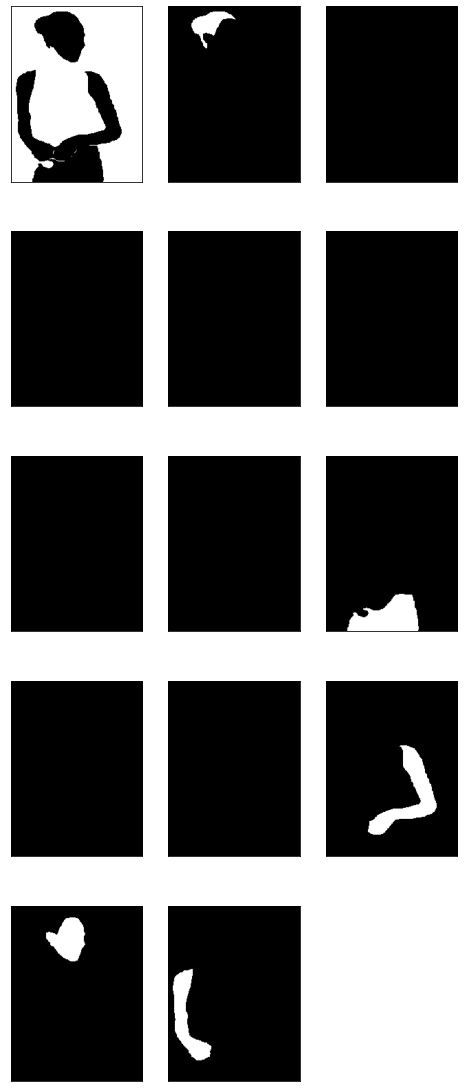

In [12]:
# 14
fig = plt.figure(figsize=(8, 20))

for i in range(14):
    ax = fig.add_subplot(5, 3, i+1)
    plt.imshow(masked_label[0][i].detach().cpu().numpy(), cmap = 'gray')
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
plt.show()

In [13]:
sigmoid = nn.Sigmoid()
G1_in = torch.cat([in_blurry, clothes, in_skeleton], dim=1)
arm_label = G1n(G1_in)
arm_label = sigmoid(arm_label)

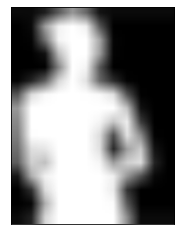

In [14]:
a, b = plt.subplots()
b.imshow(in_blurry[0].permute(1,2,0).detach().cpu().numpy(), cmap = 'gray')
b.xaxis.set_visible(False)
b.yaxis.set_visible(False)

In [15]:
arm_label.size()

torch.Size([1, 4, 256, 192])

### This is the label when mixing up the clothing

In [16]:
def generate_discrete_label(inputs, label_nc, onehot=True):
    pred_batch = []
    size = inputs.size()
    for input in inputs:
        input = input.view(1, label_nc, size[2], size[3])
        pred = np.squeeze(input.data.max(1)[1].cpu().numpy(), axis=0)
        pred_batch.append(pred)
    pred_batch = np.array(pred_batch)
    pred_batch = torch.from_numpy(pred_batch)
    label_map = []
    for p in pred_batch:
        p = p.view(1, 256, 192)
        label_map.append(p)
    label_map = torch.stack(label_map, 0)
    if not onehot:
        return label_map.float().cuda()
    size = label_map.size()
    oneHot_size = (size[0], label_nc, size[2], size[3])
    input_label = torch.cuda.FloatTensor(torch.Size(oneHot_size)).zero_()
    input_label = input_label.scatter_(1, label_map.data.long().cuda(), 1.0)
    return input_label


armlabel_map = generate_discrete_label(arm_label.detach(), 4, False)
dis_label = generate_discrete_label(arm_label.detach(), 4)

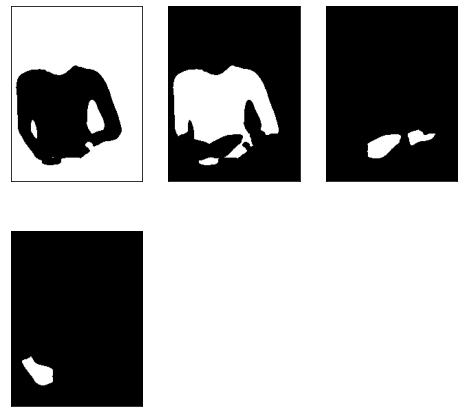

In [17]:
fig = plt.figure(figsize=(8, 20))

for i in range(4):
    ax = fig.add_subplot(5, 3, i+1)
    plt.imshow(dis_label[0][i].detach().cpu().numpy(),cmap='gray')
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
plt.show()

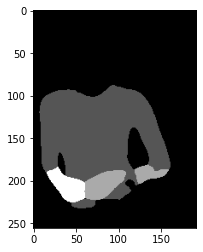

In [18]:
plt.imshow(armlabel_map[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')

In [19]:
import fix_segmentation_spot as spot

# Check for segmentation defects 

In [20]:
for image_index in range(dis_label.shape[0]): #check every segmentation in the batch
    hole_hand = dis_label[image_index].detach().cpu().numpy()
    armlabel_map_needs_updating = False
    if (spot.checkForSpots(hole_hand[3])): # left arm
        armlabel_map_needs_updating = True
        fixed_segment = spot.fixSpots(hole_hand, 3)
        hole_hand[1] = fixed_segment[1] # torso needs to be updated before checking for the other hand
        fixed_segment = torch.from_numpy(fixed_segment).to('cuda')
        dis_label[image_index][1] = fixed_segment[1]
        dis_label[image_index][3] = fixed_segment[3]
    if (spot.checkForSpots(hole_hand[2])): # right arm
        armlabel_map_needs_updating = True
        fixed_segment = spot.fixSpots(hole_hand, 2)
        fixed_segment = torch.from_numpy(fixed_segment).to('cuda')
        dis_label[image_index][1] = fixed_segment[1]
        dis_label[image_index][3] = fixed_segment[3]
    if armlabel_map_needs_updating == True:
        armlabel_map = generate_discrete_label(dis_label.detach(), 4, False)

(-0.5, 191.5, 255.5, -0.5)

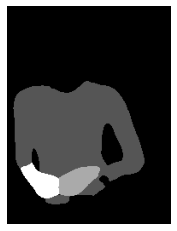

In [21]:
plt.imshow(armlabel_map[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')
plt.axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


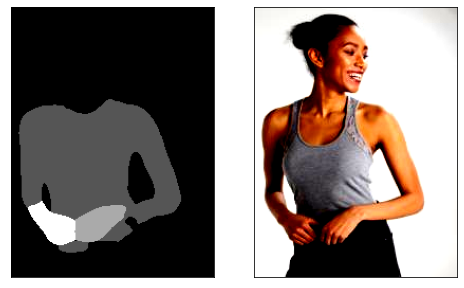

In [22]:
fig = plt.figure(figsize=(8, 20))
ax = fig.add_subplot(1, 2, 1)
plt.imshow(armlabel_map[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax = fig.add_subplot(1, 2, 2)
plt.imshow(in_image[0].permute(1,2,0).detach().cpu().numpy()+0.3)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
plt.show()

C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  """Entry point for launching an IPython kernel.


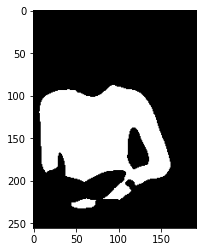

In [23]:
fake_cl = torch.FloatTensor((armlabel_map.cpu().numpy() == 1).astype(np.float)).cuda()
plt.imshow(fake_cl[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')

In [24]:
from models import networks
class GMM(nn.Module):
    def __init__(self, input_nc, output_nc=3):
        super(GMM, self).__init__()
        self.stn = networks.Net()
        nl = nn.InstanceNorm2d
        self.conv1 = nn.Sequential(*[nn.Conv2d(input_nc, 64, kernel_size=3, stride=1, padding=1), nl(64), nn.ReLU()])
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Sequential(*[nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU()])
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv3 = nn.Sequential(*[nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU()])
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv4 = nn.Sequential(*[nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU(),
                                     nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU()])
        self.drop4 = nn.Dropout(0.5)
        self.pool4 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv5 = nn.Sequential(*[nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1), nl(1024), nn.ReLU(),
                                     nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1), nl(1024), nn.ReLU()])
        self.drop5 = nn.Dropout(0.5)

# ------------------------------------------------ encoder-decoder split --------------------------------------------------------

        self.up6 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1), nl(512),
              nn.ReLU()])
        self.conv6 = nn.Sequential(*[nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU(),
                                     nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1), nl(512), nn.ReLU()])
        self.up7 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1), nl(256),
              nn.ReLU()])
        self.conv7 = nn.Sequential(*[nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1), nl(256), nn.ReLU()])
        self.up8 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1), nl(128),
              nn.ReLU()])
        self.conv8 = nn.Sequential(*[nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1), nl(128), nn.ReLU()])
        self.up9 = nn.Sequential(
            *[nn.UpsamplingNearest2d(scale_factor=2), nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1), nl(64),
              nn.ReLU()])
        self.conv9 = nn.Sequential(*[nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1), nl(64), nn.ReLU(),
                                     nn.Conv2d(
                                         64, output_nc, kernel_size=3, stride=1, padding=1)
                                     ])

    def forward(self, clothes, torso, pose):
        affine_transformed = self.stn(clothes, torso)
        conv1 = self.conv1(torch.cat([affine_transformed.detach(), torso.detach(), pose.detach()], 1))
        pool1 = self.pool1(conv1)
        conv2 = self.conv2(pool1)
        pool2 = self.pool2(conv2)
        conv3 = self.conv3(pool2)
        pool3 = self.pool3(conv3)
        conv4 = self.conv4(pool3)
        drop4 = self.drop4(conv4)
        pool4 = self.pool4(drop4)
        conv5 = self.conv5(pool4)
        drop5 = self.drop5(conv5)
        up6 = self.up6(drop5)
        conv6 = self.conv6(torch.cat([drop4, up6], 1))
        up7 = self.up7(conv6)
        conv7 = self.conv7(torch.cat([conv3, up7], 1))
        up8 = self.up8(conv7)
        conv8 = self.conv8(torch.cat([conv2, up8], 1))
        up9 = self.up9(conv8)
        conv9 = self.conv9(torch.cat([conv1, up9], 1))
        # Encoder has 7 convolution layers
        # Decoder has 10 convolution layers
        return conv9, affine_transformed

In [25]:
with torch.no_grad():
    G3 = Refine(11, 3)
    G3.cuda(opt.gpu_ids[0])
    G3.load_state_dict(torch.load('checkpoint/G3_epoch141.pth')) #186 epochs
    G3.eval()

In [26]:
with torch.no_grad():
    gmm = GMM(7,3)
    gmm.cuda(opt.gpu_ids[0])
    gmm.load_state_dict(torch.load('checkpoint/gmm_affine_21.pth'))
    gmm.eval()

In [27]:
def morpho(mask, iter, bigger=True):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    new = []
    for i in range(len(mask)):
        tem = mask[i].cpu().detach().numpy().squeeze().reshape(256, 192, 1)*255
        tem = tem.astype(np.uint8)
        if bigger:
            tem = cv2.dilate(tem, kernel, iterations=iter)
        else:
            tem = cv2.erode(tem, kernel, iterations=iter)
        tem = tem.astype(np.float64)
        tem = tem.reshape(1, 256, 192)
        new.append(tem.astype(np.float64)/255.0)
    new = np.stack(new)
    new = torch.FloatTensor(new).cuda()
    return new

def encode(label_map, size):
    label_nc = 14
    oneHot_size = (size[0], label_nc, size[2], size[3])
    input_label = torch.cuda.FloatTensor(torch.Size(oneHot_size)).zero_()
    input_label = input_label.scatter_(1, label_map.data.long().cuda(), 1.0)
    return input_label

In [28]:
def ger_average_color(mask, arms):
    color = torch.zeros(arms.shape).cuda()
    for i in range(arms.shape[0]):
        count = len(torch.nonzero(mask[i, :, :, :]))
        if count < 10:
            color[i, 0, :, :] = 0
            color[i, 1, :, :] = 0
            color[i, 2, :, :] = 0

        else:
            color[i, 0, :, :] = arms[i, 0, :, :].sum() / count
            color[i, 1, :, :] = arms[i, 1, :, :].sum() / count
            color[i, 2, :, :] = arms[i, 2, :, :].sum() / count
    return color

def morpho(mask, iter, bigger=True):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    new = []
    for i in range(len(mask)):
        tem = mask[i].cpu().detach().numpy().squeeze().reshape(256, 192, 1)*255
        tem = tem.astype(np.uint8)
        if bigger:
            tem = cv2.dilate(tem, kernel, iterations=iter)
        else:
            tem = cv2.erode(tem, kernel, iterations=iter)
        tem = tem.astype(np.float64)
        tem = tem.reshape(1, 256, 192)
        new.append(tem.astype(np.float64)/255.0)
    new = np.stack(new)
    new = torch.FloatTensor(new).cuda()
    return new

def encode(label_map, size):
    label_nc = 14
    oneHot_size = (size[0], label_nc, size[2], size[3])
    input_label = torch.cuda.FloatTensor(torch.Size(oneHot_size)).zero_()
    input_label = input_label.scatter_(1, label_map.data.long().cuda(), 1.0)
    return input_label

In [29]:
arm1_mask = torch.FloatTensor((in_label.cpu().numpy() == 11).astype(np.float)).cuda()
arm2_mask = torch.FloatTensor((in_label.cpu().numpy() == 13).astype(np.float)).cuda()
skin_color = ger_average_color((arm1_mask + arm2_mask - arm2_mask * arm1_mask),
            (arm1_mask + arm2_mask - arm2_mask * arm1_mask) * in_image)
new_arm1_mask = torch.FloatTensor(
            (armlabel_map.cpu().numpy() == 2).astype(np.float)).cuda()
new_arm2_mask = torch.FloatTensor(
            (armlabel_map.cpu().numpy() == 3).astype(np.float)).cuda()


arm1_occ = in_mask_clothes * new_arm1_mask
arm2_occ = in_mask_clothes * new_arm2_mask
bigger_arm1_occ = arm1_occ #morpho(arm1_occ, 10)
bigger_arm2_occ = arm2_occ #morpho(arm2_occ, 10)

occlude = (1 - bigger_arm1_occ * (arm2_mask + arm1_mask+in_mask_clothes)) * \
            (1 - bigger_arm2_occ * (arm2_mask + arm1_mask+in_mask_clothes))
img_hole_hand = in_img_fore * \
            (1 - in_mask_clothes) * occlude * (1 - fake_cl)
dis_label = encode(armlabel_map, armlabel_map.shape)

C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  """Entry point for launching an IPython kernel.
C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  
C:\Users\Tasin\anaconda3\envs\improve

In [30]:
def grid_sample(input, grid, canvas=None):
    output = F.grid_sample(input, grid)
    if canvas is None:
        return output
    else:
        input_mask = Variable(input.data.new(input.size()).fill_(1))
        output_mask = F.grid_sample(input_mask, grid)
        padded_output = output * output_mask + canvas * (1 - output_mask)
        return padded_output

tanh = torch.nn.Tanh()

fake_c, warped = gmm(clothes, fake_cl, in_skeleton)
fake_c=tanh(fake_c)

C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\torch\nn\functional.py:4066: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  "Default grid_sample and affine_grid behavior has changed "
C:\Users\Tasin\anaconda3\envs\improve\lib\site-packages\torch\nn\functional.py:4004: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  "Default grid_sample and affine_grid behavior has changed "


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


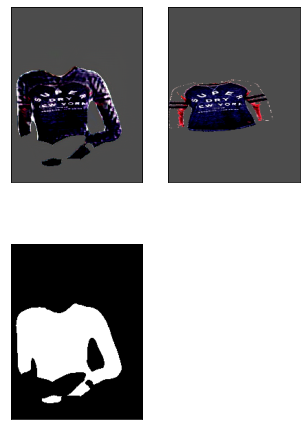

In [31]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(2, 3, 1)
plt.imshow(fake_c[0].permute(1,2,0).detach().cpu().numpy() + 0.3)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax = fig.add_subplot(2, 3, 2)
plt.imshow(warped[0].permute(1,2,0).detach().cpu().numpy() + 0.3)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
#ax = fig.add_subplot(2, 3, 3)
#plt.imshow(warped_mask[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')
#ax.xaxis.set_visible(False)
#ax.yaxis.set_visible(False)
ax = fig.add_subplot(2, 3, 4)
plt.imshow(fake_cl[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
plt.show()

In [32]:
for image_index in range(img_hole_hand.shape[0]): #check every segmentation in the batch
    preserved = img_hole_hand[image_index].permute(1,2,0).detach().cpu().numpy()
    generate_map = armlabel_map[image_index].permute(1,2,0).detach().cpu().numpy()
    size = generate_map.shape
    for i in range(size[0]):
        for j in range(size[1]):
            if preserved[i][j][0] > 0:
                generate_map[i][j] = 0
transform_A = get_transform(method=Image.NEAREST, normalize=False)
generate_map = transform_A(generate_map).cuda()

In [33]:
generate_map=generate_map.unsqueeze(0)

(-0.5, 191.5, 255.5, -0.5)

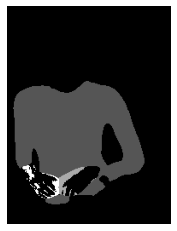

In [34]:
plt.imshow(generate_map[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')
plt.axis("off")

In [35]:
G3_in = torch.cat([img_hole_hand, generate_map, fake_c, skin_color, gen_noise(shape)], 1)
fake_image = G3(G3_in.detach())
fake_image = tanh(fake_image)

(-0.5, 191.5, 255.5, -0.5)

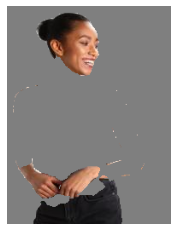

In [36]:
tensor = (img_hole_hand[0].clone() + 1) * 0.5 * 255
tensor = tensor.cpu().clamp(0, 255)
array = tensor.detach().numpy().astype('uint8')
array = array.swapaxes(0, 1).swapaxes(1, 2)
plt.imshow(array)
plt.axis("off")

(-0.5, 191.5, 255.5, -0.5)

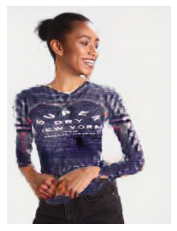

In [37]:
tensor = (fake_image[0].clone() + 1) * 0.5 * 255
tensor = tensor.cpu().clamp(0, 255)
array = tensor.detach().numpy().astype('uint8')
array = array.swapaxes(0, 1).swapaxes(1, 2)
plt.imshow(array)
plt.axis("off")
#plt.savefig('books_read.png')

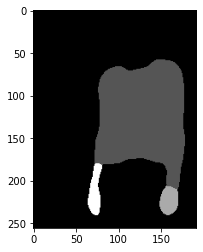

In [37]:
plt.imshow(armlabel_map[0].permute(1,2,0).detach().cpu().numpy(), cmap = 'gray')

In [37]:
input_pool=[G1_in,G3_in,torch.cat([in_mask_clothes,clothes],1)]        ##fake_cl_dis to replace
real_pool=[masked_label,in_image,in_image*in_mask_clothes]
fake_pool=[arm_label,fake_image,fake_c]

### Ground Truth Images

We use this to calculate the loss against the generated ones

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


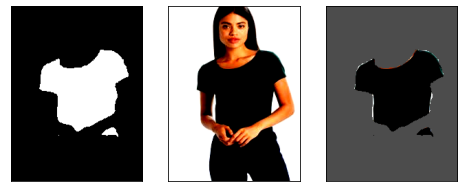

In [37]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(2, 3, 1)
plt.imshow(in_mask_clothes[0].permute(1,2,0).detach().cpu().numpy(), cmap='gray')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax = fig.add_subplot(2, 3, 2)
plt.imshow(in_image[0].permute(1,2,0).detach().cpu().numpy()+0.3)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax = fig.add_subplot(2, 3, 3)
plt.imshow((in_image*in_mask_clothes)[0].permute(1,2,0).detach().cpu().numpy()+0.3)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
plt.show()

## Fake Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


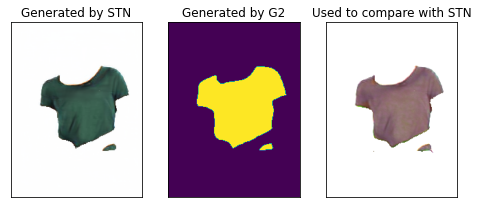

In [38]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(2, 3, 1)
plt.imshow(fake_c[0].permute(1,2,0).detach().cpu().numpy()+1)
plt.title("Generated by STN")
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax = fig.add_subplot(2, 3, 2)
plt.imshow(fake_cl[0].permute(1,2,0).detach().cpu().numpy())
plt.title("Generated by G2")
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax = fig.add_subplot(2, 3, 3)
plt.imshow((fake_image*in_mask_clothes)[0].permute(1,2,0).detach().cpu().numpy()+1)
plt.title("Used to compare with STN")

ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
plt.show()

## How to calculate loss

In [ ]:
class ImagePool():
    def __init__(self, pool_size):
        self.pool_size = pool_size
        if self.pool_size > 0:
            self.num_imgs = 0
            self.images = []

    def query(self, images):
        if self.pool_size == 0:
            return images
        return_images = []
        for image in images.data:
            image = torch.unsqueeze(image, 0)
            if self.num_imgs < self.pool_size:
                self.num_imgs = self.num_imgs + 1
                self.images.append(image)
                return_images.append(image)
            else:
                p = random.uniform(0, 1)
                if p > 0.5:
                    random_id = random.randint(0, self.pool_size-1)
                    tmp = self.images[random_id].clone()
                    self.images[random_id] = image
                    return_images.append(tmp)
                else:
                    return_images.append(image)
        return_images = Variable(torch.cat(return_images, 0))
        return return_images

def discriminate(netD ,input_label, test_image, use_pool=False):
    input_concat = torch.cat((input_label, test_image.detach()), dim=1)
    fake_pool = ImagePool(opt.pool_size)
    fake_query = fake_pool.query(input_concat)
    return netD.forward(fake_query)

In [ ]:
from models import networks
D3 = networks.define_D(7, opt.ndf, opt.n_layers_D, opt.norm, opt.no_lsgan,
                                 opt.num_D, not opt.no_ganFeat_loss, gpu_ids=opt.gpu_ids)

fake_pool_for_stn = discriminate(D3, torch.cat([in_mask_clothes,in_color],1).detach(), fake_c, use_pool=True)
real_pool_for_stn = discriminate(D3, torch.cat([in_mask_clothes,in_color],1).detach(), in_image*in_mask_clothes, use_pool=True)

In [ ]:
loss_D_fake=0
loss_D_real=0
loss_G_GAN=0
loss_G_VGG = 0

In [ ]:
criterionGAN = networks.GANLoss(use_lsgan=not opt.no_lsgan, tensor=torch.cuda.FloatTensor) 
loss_D_fake += criterionGAN(fake_pool_for_stn, False)    
loss_D_real += criterionGAN(real_pool_for_stn, True)

In [ ]:
input_data = torch.cat([in_mask_clothes,in_color],1)
pred_fake = D3.forward(torch.cat((input_data.detach(), fake_c), dim=1))
loss_G_GAN += criterionGAN(pred_fake, True)

In [ ]:
criterionVGG = networks.VGGLoss(opt.gpu_ids)
comp_fake_c=fake_c.detach()*(1-composition_mask).unsqueeze(1)+(composition_mask.unsqueeze(1))*warped.detach()
loss_G_VGG += criterionVGG.warp(warped, in_image*in_mask_clothes)+ criterionVGG.warp(comp_fake_c, in_image*in_mask_clothes) * 10
loss_G_VGG += criterionVGG.warp(fake_c, in_image*in_mask_clothes) *20

criterionFeat = torch.nn.L1Loss()

L1_loss = criterionFeat(warped_mask,in_mask_clothes)+criterionFeat(warped, in_image*in_mask_clothes)
L1_loss+= criterionFeat(fake_c, in_image*in_mask_clothes)*0.2
L1_loss+= criterionFeat(comp_fake_c, in_image*in_mask_clothes)*10
L1_loss+= criterionFeat(composition_mask,in_mask_clothes)

In [ ]:
plt.imshow(composition_mask[0].detach().cpu().numpy()+1)
